#### Problem
Implement LDA (step-by-step) on IRIS dataset. 

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
import numpy as np
iris_features = np.array(iris.data)
iris_target = np.array(iris.target)
iris_features, iris_features.shape, iris_target, iris_target.shape

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [3]:
uniques = np.unique(iris_target)
class_wise_samples = []
for value in uniques:
    temp = iris_features[iris_target==value]
    class_wise_samples.append(temp)
class_wise_samples, len(class_wise_samples), len(class_wise_samples[0])

([array([[5.1, 3.5, 1.4, 0.2],
         [4.9, 3. , 1.4, 0.2],
         [4.7, 3.2, 1.3, 0.2],
         [4.6, 3.1, 1.5, 0.2],
         [5. , 3.6, 1.4, 0.2],
         [5.4, 3.9, 1.7, 0.4],
         [4.6, 3.4, 1.4, 0.3],
         [5. , 3.4, 1.5, 0.2],
         [4.4, 2.9, 1.4, 0.2],
         [4.9, 3.1, 1.5, 0.1],
         [5.4, 3.7, 1.5, 0.2],
         [4.8, 3.4, 1.6, 0.2],
         [4.8, 3. , 1.4, 0.1],
         [4.3, 3. , 1.1, 0.1],
         [5.8, 4. , 1.2, 0.2],
         [5.7, 4.4, 1.5, 0.4],
         [5.4, 3.9, 1.3, 0.4],
         [5.1, 3.5, 1.4, 0.3],
         [5.7, 3.8, 1.7, 0.3],
         [5.1, 3.8, 1.5, 0.3],
         [5.4, 3.4, 1.7, 0.2],
         [5.1, 3.7, 1.5, 0.4],
         [4.6, 3.6, 1. , 0.2],
         [5.1, 3.3, 1.7, 0.5],
         [4.8, 3.4, 1.9, 0.2],
         [5. , 3. , 1.6, 0.2],
         [5. , 3.4, 1.6, 0.4],
         [5.2, 3.5, 1.5, 0.2],
         [5.2, 3.4, 1.4, 0.2],
         [4.7, 3.2, 1.6, 0.2],
         [4.8, 3.1, 1.6, 0.2],
         [5.4, 3.4, 1.5, 0.4],
        

In [4]:
means = []
class_sum = np.zeros(iris_features.shape[1])
print(class_sum)
counts = 0
for class_Sample in class_wise_samples:
    class_mean = np.mean(class_Sample,axis=0)
    class_sum += np.sum(class_Sample,axis=0)
    counts += len(class_Sample)
    means.append(class_mean)
overall_mean = class_sum/counts
means,class_sum,counts,overall_mean

[0. 0. 0. 0.]


([array([5.006, 3.428, 1.462, 0.246]),
  array([5.936, 2.77 , 4.26 , 1.326]),
  array([6.588, 2.974, 5.552, 2.026])],
 array([876.5, 458.6, 563.7, 179.9]),
 150,
 array([5.84333333, 3.05733333, 3.758     , 1.19933333]))

In [5]:
sb = np.zeros([iris_features.shape[1],iris_features.shape[1]])
for class_sample,mean in zip(class_wise_samples,means):
    n= len(class_sample)
    print(n)
    temp_sb = n*np.matmul((mean-overall_mean).reshape(-1,1),(mean-overall_mean).reshape(1,-1))
    sb+=temp_sb
sb,sb.shape

50
50
50


(array([[ 63.21213333, -19.95266667, 165.2484    ,  71.27933333],
        [-19.95266667,  11.34493333, -57.2396    , -22.93266667],
        [165.2484    , -57.2396    , 437.1028    , 186.774     ],
        [ 71.27933333, -22.93266667, 186.774     ,  80.41333333]]),
 (4, 4))

## Transpose of a 1D Array in NumPy

### 🔑 Core Idea

In **NumPy**, a 1D array is **not treated as a matrix**.

```python
import numpy as np

v = np.array([1, 2, 3])

Shape:

v.shape  # (3,)

👉 This is neither (1 × n) nor (n × 1) — it has no orientation

🔍 What happens when you transpose?
v.T

Result:

array([1, 2, 3])

Shape:

(3,)

👉 No change occurs

⚠️ Why this happens

Transpose is defined for 2D matrices, but:

A 1D array has only one axis
There is no row/column distinction

So NumPy leaves it unchanged.

🧠 Important distinction (Theory vs NumPy)
Concept	Linear Algebra	NumPy
Vector	Column by default (n×1)	1D array (n,)
Transpose	(n×1) → (1×n)	No effect on (n,)
✅ How to get proper transpose behavior
🔹 Column vector 
(
𝑛
×
1
)
(n×1)
v_col = v.reshape(-1, 1)

Shape:

(3, 1)
🔹 Row vector 
(
1
×
𝑛
)
(1×n)
v_row = v.reshape(1, -1)

Shape:

(1, 3)
🔁 Now transpose works correctly
v_col.T  # (1, 3)
v_row.T  # (3, 1)
🔥 Why this matters

If you do:

np.matmul(v.T, v)

👉 Since both are (n,), this becomes:

Dot product → scalar

But if you want a matrix:

v_col = v.reshape(-1, 1)
v_col @ v_col.T

👉 Result:

Shape: (n, n) → matrix (outer product)
🎯 Final Takeaway
1D arrays in NumPy have no orientation
.T does nothing on shape (n,)
Use .reshape() to explicitly define:
Row vector (1, n)
Column vector (n, 1)

if n is -1, it means infer the dimension automatically

In [6]:
sw = np.zeros([iris_features.shape[1],iris_features.shape[1]])
for class_sample,mean in zip(class_wise_samples,means):
    d1 = class_sample - mean
    temp_sw = np.matmul(np.transpose(d1),d1)
    sw += temp_sw
sw,sw.shape

(array([[38.9562, 13.63  , 24.6246,  5.645 ],
        [13.63  , 16.962 ,  8.1208,  4.8084],
        [24.6246,  8.1208, 27.2226,  6.2718],
        [ 5.645 ,  4.8084,  6.2718,  6.1566]]),
 (4, 4))

In [7]:
final_Scatter_matrix = np.matmul(np.linalg.inv(sw),sb)
final_Scatter_matrix

array([[ -3.05836939,   1.08138264,  -8.1119227 ,  -3.45864987],
       [ -5.56163926,   2.17821866, -14.96461194,  -6.30773951],
       [  8.07743878,  -2.94271854,  21.5115909 ,   9.14206468],
       [ 10.49708187,  -3.41985449,  27.54852482,  11.84588007]])

In [8]:
values,vectors = np.linalg.eigh(final_Scatter_matrix)
values,vectors

(array([-12.63630914,  -7.08180558,   3.55392377,  48.64151119]),
 array([[ 0.44376856,  0.77159596, -0.37842983,  0.2539685 ],
        [ 0.09525583,  0.42332075,  0.89258491, -0.12254813],
        [ 0.49887403, -0.40814427,  0.23999316,  0.72591063],
        [-0.73832276,  0.24260558,  0.04986302,  0.62732425]]))

In [9]:
##for sample 0
y = np.matmul(class_wise_samples[0],vectors[:,3])
y

array([2.00806064, 2.018541  , 1.87064661, 2.0026867 , 1.97040897,
       2.37846997, 1.95606362, 2.06750966, 1.90381156, 2.01614482,
       2.13233262, 2.08930702, 1.93041172, 1.58565429, 1.9793824 ,
       2.24820433, 2.08810572, 2.07079306, 2.40418291, 2.10661969,
       2.31427919, 2.18160692, 1.57845732, 2.43854073, 2.30708021,
       2.18911997, 2.26556557, 2.10604855, 2.0457123 , 2.0884198 ,
       2.12607146, 2.29456191, 1.96978725, 2.02386435, 2.07887725,
       1.8742461 , 2.03705697, 1.8822797 , 1.81896569, 2.09290651,
       1.97280515, 1.99287865, 1.79445606, 2.37877561, 2.45971636,
       2.05587657, 2.11647832, 1.91784082, 2.10693577, 2.00717341])

In [10]:
y = np.matmul(class_wise_samples[1],vectors[:,3])
y

array([5.6756594 , 5.4408286 , 5.87043191, 4.8341301 , 5.58783576,
       5.18660505, 5.61109149, 3.97315947, 5.47551295, 4.69906166,
       4.1927577 , 5.12058078, 4.78517188, 5.48385219, 4.49563382,
       5.39395047, 5.26216342, 4.74569518, 5.51258302, 4.63696141,
       5.71981481, 4.92523713, 5.79157969, 5.37064215, 5.20694606,
       5.38080844, 5.74647601, 6.02994894, 5.37600564, 4.29700677,
       4.55122831, 4.41590482, 4.72597791, 5.89879406, 5.21136972,
       5.377464  , 5.67445609, 5.32766915, 4.84633432, 4.80962047,
       5.02499748, 5.39900631, 4.81082378, 4.01081113, 4.95568982,
       4.88158981, 4.95657705, 5.15615236, 3.85665759, 4.8962408 ])

In [11]:
y = np.matmul(class_wise_samples[2],vectors[:,3])
y

array([7.11936713, 6.03619764, 7.0357856 , 6.43889515, 6.87354587,
       7.67090729, 5.27112439, 7.20100109, 6.73468393, 7.3837654 ,
       6.21543395, 6.33376086, 6.6692308 , 6.02545178, 6.33760495,
       6.5234165 , 6.40484298, 7.73358913, 8.08856143, 5.82474464,
       6.940765  , 5.89069943, 7.73067241, 5.95526734, 6.75225164,
       6.92106661, 5.84502461, 5.8677092 , 6.66474409, 6.67492926,
       7.15620305, 7.44114479, 6.72747652, 5.89999737, 6.17393619,
       7.45881368, 6.75401564, 6.36719131, 5.76972129, 6.60978178,
       6.89236748, 6.51747344, 6.03619764, 7.06055028, 7.00318134,
       6.55152561, 6.11510045, 6.31253464, 6.52070424, 5.96209762])

In [12]:
##for all fatures
y = np.matmul(iris_features,vectors[:,3])
y

array([2.00806064, 2.018541  , 1.87064661, 2.0026867 , 1.97040897,
       2.37846997, 1.95606362, 2.06750966, 1.90381156, 2.01614482,
       2.13233262, 2.08930702, 1.93041172, 1.58565429, 1.9793824 ,
       2.24820433, 2.08810572, 2.07079306, 2.40418291, 2.10661969,
       2.31427919, 2.18160692, 1.57845732, 2.43854073, 2.30708021,
       2.18911997, 2.26556557, 2.10604855, 2.0457123 , 2.0884198 ,
       2.12607146, 2.29456191, 1.96978725, 2.02386435, 2.07887725,
       1.8742461 , 2.03705697, 1.8822797 , 1.81896569, 2.09290651,
       1.97280515, 1.99287865, 1.79445606, 2.37877561, 2.45971636,
       2.05587657, 2.11647832, 1.91784082, 2.10693577, 2.00717341,
       5.6756594 , 5.4408286 , 5.87043191, 4.8341301 , 5.58783576,
       5.18660505, 5.61109149, 3.97315947, 5.47551295, 4.69906166,
       4.1927577 , 5.12058078, 4.78517188, 5.48385219, 4.49563382,
       5.39395047, 5.26216342, 4.74569518, 5.51258302, 4.63696141,
       5.71981481, 4.92523713, 5.79157969, 5.37064215, 5.20694

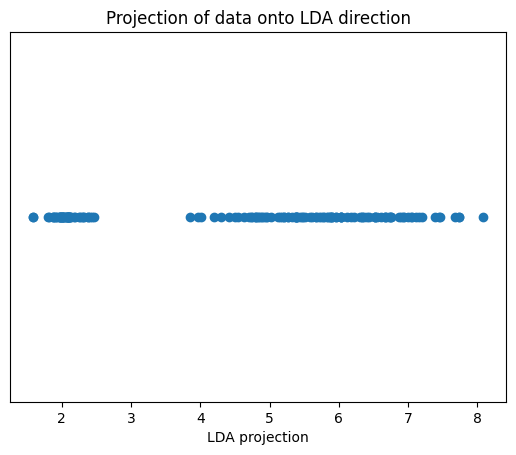

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y, [0]*len(y))

plt.xlabel("LDA projection")
plt.title("Projection of data onto LDA direction")
plt.yticks([])  # remove y-axis since it's meaningless here
plt.show()

In [15]:
ranges = []
for class_Sample in class_wise_samples:
    y = np.matmul(class_Sample,vectors[:,3])
    ranges.append((np.min(y),np.max(y),np.mean(y)))
ranges

[(1.5784573216801667, 2.4597163612507678, 2.06687443623687),
 (3.8566575941919883, 6.02994893718389, 5.092309937319735),
 (5.271124385974507, 8.08856143198568, 6.609901088914886)]

## Axis in NumPy vs Pandas — Complete Unified Understanding

### 🔑 Core Idea

In **both NumPy and Pandas**:

- `axis=0` → operate **down rows** (vertical) → result is **column-wise**
- `axis=1` → operate **across columns** (horizontal) → result is **row-wise**

---

### 🧠 Why Confusion Happens

People often say:

> "axis=1 means columns"

But what they actually mean is:

> "operation is performed **across columns**"

NOT that the result gives column-wise outputs.

---

### 🔍 Example (Pandas — Mean)

```python
import pandas as pd

df = pd.DataFrame({
    'A': [1, 3],
    'B': [2, 4]
})
✅ axis = 0 (column-wise mean)
df.mean(axis=0)

Result:

A → 2
B → 3
✅ axis = 1 (row-wise mean)
df.mean(axis=1)

Result:

0 → 1.5
1 → 3.5
🔍 Example (NumPy — Mean)
import numpy as np

X = np.array([
    [1, 2],
    [3, 4]
])
axis = 0
np.mean(X, axis=0)  # [2, 3]
axis = 1
np.mean(X, axis=1)  # [1.5, 3.5]
🔍 Example (Pandas — Drop)
new_Df_short = new_df.drop(["City","StateProvinceName"], axis=1)

👉 axis=1 means:

Operate across columns
Remove specified columns
Before:
City	StateProvinceName	Age
A	X	25
B	Y	30
After:
Age
25
30
🔥 Mental Model (Remember This)
axis	Meaning	Direction	Result
axis=0	collapse rows	↓ vertical	column-wise
axis=1	collapse columns	→ horizontal	row-wise
🎯 One-Line Trick

👉 axis = direction you move along

axis=0 → move down (↓)
axis=1 → move across (→)
🧠 Final Takeaway
NumPy and Pandas behave the same
Confusion comes from wording, not implementation
Use:
axis=0 → feature-wise operations (ML, PCA, SVD)
axis=1 → per-sample operations or column-wise actions (like dropping columns)